<a href="https://colab.research.google.com/github/NEFAxRAJ/Machine-Learning-Practices/blob/main/Multi_linear_Logistic_Regression_from_mathematical_intuition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = {
    'Feature1': np.random.rand(100) * 10,
    'Feature2': np.random.rand(100)*5,
    'Feature3': np.random.rand(100)*2
}
data['Target']= np.where(data['Feature1']+data['Feature2']+data['Feature3']>8.0,
                         1,
                         0     )
dataset=pd.DataFrame(data)

In [ ]:
dataset.head()

,Feature1,Feature2,Feature3,Target
0,4.765052,3.008403,0.349309,1
1,5.380241,0.304259,1.228484,0
2,5.730135,1.879549,1.863716,1
3,7.289483,3.615057,0.682801,1
4,8.127194,4.395052,1.233534,1


In [ ]:
x_data=dataset.drop('Target',axis=1)

y_data=dataset['Target']


In [ ]:
from sklearn.model_selection import train_test_split
x,x_test,y,y_test=train_test_split(x_data,y_data, train_size=0.2,random_state=2)

In [ ]:
def hypothesis(w,x,c):
  z=np.dot(x,w)+c
  h=sigmoid(z)
  return h

def sigmoid(z):
  z=1/(1+np.exp(-z))
  return z

In [ ]:
def costfunc(w,x,y,c):
  h=hypothesis(w,x,c)
  cost= -y*np.log(h)-(1-y)*np.log(1-h)
  cost=np.mean(cost)
  return cost

In [ ]:

def gradient_descent(x,y,learning_rate):
  m,n=x.shape
  w=np.zeros(n)
  c=0
  tcost=0
  for i in range(10000):
    new_w,new_c=gradientfunction(w,c,x,y,m)
    w=w-learning_rate*(new_w)
    c=c-learning_rate*(new_c)
    if(i%500==0):
      tcost=costfunc(w,x,y,c)
      print('Cost at ',i,' th interation is: ', tcost)
  return w,c;

def gradientfunction(w,c,x,y,m):
  err=hypothesis(w,x,c)-y
  new_w=np.sum(np.dot(x.T,err))
  new_c=np.sum(err)
  return new_w/m,new_c/m

In [ ]:
learning_rate=0.1

w,c=gradient_descent(x,y,learning_rate)
print(w,c)

Cost at  0  th interation is:  0.6713512635523953
Cost at  500  th interation is:  0.25836446609887476
Cost at  1000  th interation is:  0.2053432155427335
Cost at  1500  th interation is:  0.18261807850069536
Cost at  2000  th interation is:  0.16929027903739544
Cost at  2500  th interation is:  0.1602136180788435
Cost at  3000  th interation is:  0.15346978952313137
Cost at  3500  th interation is:  0.1481668723563414
Cost at  4000  th interation is:  0.1438281857737103
Cost at  4500  th interation is:  0.14017319598343306
Cost at  5000  th interation is:  0.13702468620763492
Cost at  5500  th interation is:  0.13426445653486802
Cost at  6000  th interation is:  0.13181020510316172
Cost at  6500  th interation is:  0.12960258956809528
Cost at  7000  th interation is:  0.12759756713247147
Cost at  7500  th interation is:  0.12576164487625402
Cost at  8000  th interation is:  0.12406881825447671
Cost at  8500  th interation is:  0.12249853160851416
Cost at  9000  th interation is:  0.1

In [ ]:
def predict(x, w, b):
    z = np.dot(x, w) + b
    h = sigmoid(z)
    return (h >= 0.5).astype(int)

In [ ]:
predictions = predict(x_test, w, c)

In [ ]:
predictions

array([1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1])

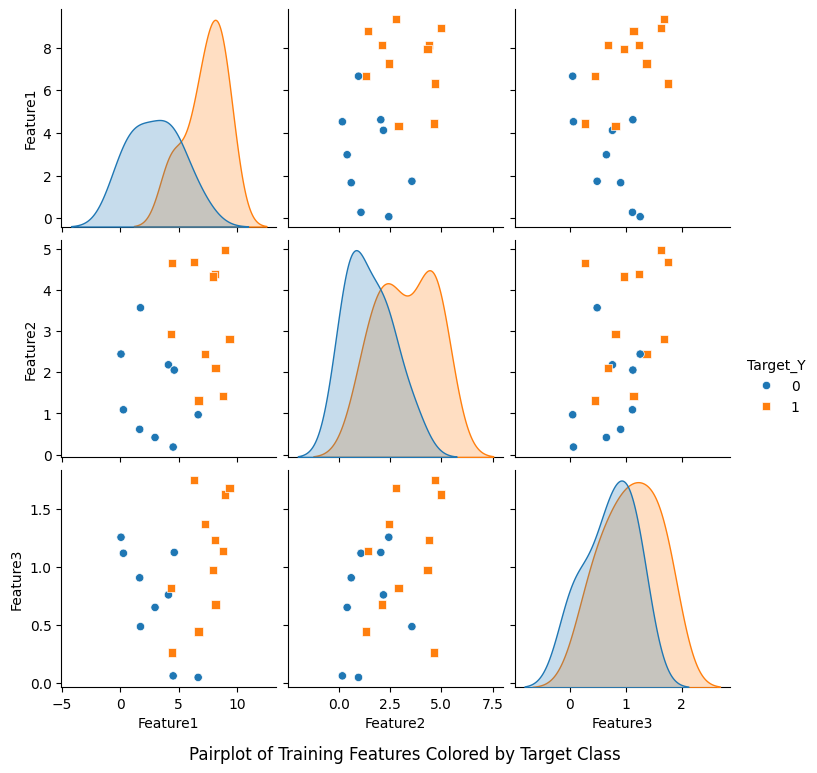

In [ ]:


# Combine X_train and y_train into a single DataFrame
train_df = x.copy()
train_df['Target_Y'] = y

# Create the pairplot
# 'hue="Target_Y"' colors the points based on the target value (0 or 1)
sns.pairplot(train_df, hue='Target_Y', markers=["o", "s"])
plt.suptitle('Pairplot of Training Features Colored by Target Class', y=0)
plt.show()
